### NAME          : PARTHAM RAJU
### BATCH         : AI IN DATA ANALYTICS
### JOINED        : MAY 2026
### QUALIFICATION : B.TECH-IT

## Employee Attrition Analysis Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
COLOR_LEFT = '#E15759'
COLOR_STAY = '#4E79A7'
PALETTE3 = ['#4E79A7', '#E15759', '#F28E2B']

##### Description:

In this step, a white grid theme is applied to all visualizations using Seaborn's set_style() function. This provides a clean background with grid lines that improve chart readability. Additionally, custom color variables are created to represent different employee categories consistently across all charts. These colors are reused throughout the project to maintain a uniform appearance in every visualization.

In [3]:
df = pd.read_csv(r"C:\Users\rajun\Downloads\datasetproject\WA_Fn-UseC_-HR-Employee-Attrition.csv")

##### Description:

The HR Employee Attrition dataset is imported into Python using the read_csv() function and stored in a DataFrame named df. The dataset contains employee information such as age, department, education, salary, work experience, overtime status, job satisfaction, and attrition details. Once loaded successfully, the dataset becomes available for data cleaning, exploratory analysis, feature engineering, and visualization

In [4]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


#### Description:

he head(10) function displays the first ten rows of the employee dataset. This provides a quick preview of the available data and helps understand the overall structure of the dataset. It displays sample employee records, including important attributes such as employee age, department, business travel frequency, education level, monthly income, job role, overtime status, and attrition status. By viewing these records, the analyst can verify that the dataset has been imported correctly and gain an initial understanding of the available variables.

### STEP 1: Understand the Dataset + Data Dictionary

In [5]:
print(df.shape)

(1470, 35)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

##### Description:

The info() function provides a detailed summary of the dataset. It displays the total number of rows, column names, data types, non-null values, and memory usage. This information helps understand the structure of the dataset and confirms whether each column contains the correct data type. In this project, the output shows that all columns have 1,470 non-null values, indicating that there are no missing values in the dataset.

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


#### Description:

The describe() function generates descriptive statistics for all numerical columns in the dataset. It calculates important statistical measures such as count, mean, standard deviation, minimum value, maximum value, and quartiles. These statistics provide a quick understanding of the distribution and variation of numerical variables like employee age, monthly income, total working years, and daily pay rate.

In [8]:
for col in df.columns:
    print(col, "->", df[col].nunique(), "unique values")

Age -> 43 unique values
Attrition -> 2 unique values
BusinessTravel -> 3 unique values
DailyRate -> 886 unique values
Department -> 3 unique values
DistanceFromHome -> 29 unique values
Education -> 5 unique values
EducationField -> 6 unique values
EmployeeCount -> 1 unique values
EmployeeNumber -> 1470 unique values
EnvironmentSatisfaction -> 4 unique values
Gender -> 2 unique values
HourlyRate -> 71 unique values
JobInvolvement -> 4 unique values
JobLevel -> 5 unique values
JobRole -> 9 unique values
JobSatisfaction -> 4 unique values
MaritalStatus -> 3 unique values
MonthlyIncome -> 1349 unique values
MonthlyRate -> 1427 unique values
NumCompaniesWorked -> 10 unique values
Over18 -> 1 unique values
OverTime -> 2 unique values
PercentSalaryHike -> 15 unique values
PerformanceRating -> 2 unique values
RelationshipSatisfaction -> 4 unique values
StandardHours -> 1 unique values
StockOptionLevel -> 4 unique values
TotalWorkingYears -> 40 unique values
TrainingTimesLastYear -> 7 unique va

#### Description:

This step calculates the number of unique values present in each column of the dataset. It helps understand the diversity of data stored in every variable. For example, the Attrition column has two unique values (Yes and No), while Employee Number contains unique values for every employee. It also identifies columns that contain only a single unique value, which may not contribute useful information to the analysis.

In [9]:
rename_map = {
    'Age': 'Employee Age',
    'Attrition': 'Attrition Status',
    'BusinessTravel': 'Business Travel',
    'DailyRate': 'Daily Pay Rate',
    'DistanceFromHome': 'Distance from Home',
    'Education': 'Education Level',
    'EducationField': 'Education Field',
    'EmployeeCount': 'Employee Count',
    'EmployeeNumber': 'Employee ID',
    'EnvironmentSatisfaction': 'Environment Satisfaction',
    'HourlyRate': 'Hourly Pay Rate',
    'JobInvolvement': 'Job Involvement',
    'JobLevel': 'Job Level',
    'JobRole': 'Job Role',
    'JobSatisfaction': 'Job Satisfaction',
    'MaritalStatus': 'Marital Status',
    'MonthlyIncome': 'Monthly Income',
    'MonthlyRate': 'Monthly Pay Rate',
    'NumCompaniesWorked': 'Previous Companies Worked',
    'Over18': 'Age Above 18',
    'OverTime': 'Overtime',
    'PercentSalaryHike': 'Salary Hike (%)',
    'PerformanceRating': 'Performance Rating',
    'RelationshipSatisfaction': 'Relationship Satisfaction',
    'StandardHours': 'Standard Working Hours',
    'StockOptionLevel': 'Stock Option Level',
    'TotalWorkingYears': 'Total Working Years',
    'TrainingTimesLastYear': 'Training Sessions Last Year',
    'WorkLifeBalance': 'Work-Life Balance',
    'YearsAtCompany': 'Years at Company',
    'YearsInCurrentRole': 'Years in Current Role',
    'YearsSinceLastPromotion': 'Years Since Last Promotion',
    'YearsWithCurrManager': 'Years with Current Manager',
}

#### Description:

A dictionary named rename_map is created to replace the original column names with more meaningful and readable names. For example, Age is renamed to Employee Age, JobRole becomes Job Role, and MonthlyIncome becomes Monthly Income. This improves the readability of the dataset and makes the column names easier to understand during analysis and visualization.

In [10]:
df = df.rename(columns=rename_map)
print("\nRenamed columns:\n", df.columns.tolist())


Renamed columns:
 ['Employee Age', 'Attrition Status', 'Business Travel', 'Daily Pay Rate', 'Department', 'Distance from Home', 'Education Level', 'Education Field', 'Employee Count', 'Employee ID', 'Environment Satisfaction', 'Gender', 'Hourly Pay Rate', 'Job Involvement', 'Job Level', 'Job Role', 'Job Satisfaction', 'Marital Status', 'Monthly Income', 'Monthly Pay Rate', 'Previous Companies Worked', 'Age Above 18', 'Overtime', 'Salary Hike (%)', 'Performance Rating', 'Relationship Satisfaction', 'Standard Working Hours', 'Stock Option Level', 'Total Working Years', 'Training Sessions Last Year', 'Work-Life Balance', 'Years at Company', 'Years in Current Role', 'Years Since Last Promotion', 'Years with Current Manager']


### STEP 2: Data Cleaning

In [11]:
print("Nulls:\n", df.isnull().sum())

Nulls:
 Employee Age                   0
Attrition Status               0
Business Travel                0
Daily Pay Rate                 0
Department                     0
Distance from Home             0
Education Level                0
Education Field                0
Employee Count                 0
Employee ID                    0
Environment Satisfaction       0
Gender                         0
Hourly Pay Rate                0
Job Involvement                0
Job Level                      0
Job Role                       0
Job Satisfaction               0
Marital Status                 0
Monthly Income                 0
Monthly Pay Rate               0
Previous Companies Worked      0
Age Above 18                   0
Overtime                       0
Salary Hike (%)                0
Performance Rating             0
Relationship Satisfaction      0
Standard Working Hours         0
Stock Option Level             0
Total Working Years            0
Training Sessions Last Year    0
Wo

##### Description:

The isnull().sum() function is used to count the number of missing values in each column of the dataset. It checks every column individually and returns the total number of null values present. In this project, the output shows zero missing values for all columns, indicating that the dataset is complete and does not require any missing value treatment.

In [12]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


#### Description:

The duplicated().sum() function is used to identify duplicate rows in the dataset. Duplicate records can occur due to repeated data entry or data collection errors and may affect the accuracy of the analysis. In this project, the output shows 0 duplicate records, indicating that each employee record is unique.

In [13]:
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns:", constant_cols)   # Employee Count, Standard Working Hours, Age Above 18

Constant columns: ['Employee Count', 'Age Above 18', 'Standard Working Hours']


#### Description:

In this step, the dataset is checked to identify columns that contain only one unique value across all employee records. Such columns are known as constant columns because every row contains the same value. The output shows that Employee Count, Age Above 18, and Standard Working Hours are constant columns. Since these columns do not vary from one employee to another, they do not provide any useful information for analysis or prediction.

#### Why this step is used:

Constant columns do not contribute to data analysis because they contain the same value for every record. Keeping them only increases the dataset size without adding meaningful insights. Removing these columns simplifies the dataset and improves the efficiency of analysis.

In [14]:
df_clean = df.drop(columns=constant_cols)

In [15]:
df_clean['Business Travel'] = df_clean['Business Travel'].replace({
    'TravelRarely': 'Travel Rarely',
    'TravelFrequently': 'Travel Frequently',
    'NonTravel': 'Non Travel'
})

#### Description:

In this step, the values in the Business Travel column are modified to improve readability. The original values such as TravelRarely, TravelFrequently, and NonTravel are replaced with Travel Rarely, Travel Frequently, and Non Travel. This formatting makes the category names more understandable and easier to display in reports and visualizations.

#### Why this step is used:

Cleaning categorical values improves data consistency and makes the dataset more user-friendly. Properly formatted category names enhance the readability of charts, tables, and dashboards, making the analysis easier to interpret.

In [16]:
df_clean['Business Travel'].head(20)

0         Travel_Rarely
1     Travel_Frequently
2         Travel_Rarely
3     Travel_Frequently
4         Travel_Rarely
5     Travel_Frequently
6         Travel_Rarely
7         Travel_Rarely
8     Travel_Frequently
9         Travel_Rarely
10        Travel_Rarely
11        Travel_Rarely
12        Travel_Rarely
13        Travel_Rarely
14        Travel_Rarely
15        Travel_Rarely
16        Travel_Rarely
17           Non-Travel
18        Travel_Rarely
19        Travel_Rarely
Name: Business Travel, dtype: object

#### Checking Outliers

In [17]:
def count_outliers(col):
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((df_clean[col] < low) | (df_clean[col] > high)).sum()
 
for col in ['Monthly Income', 'Total Working Years', 'Years at Company', 'Previous Companies Worked']:
    print(col, count_outliers(col))

Monthly Income 114
Total Working Years 63
Years at Company 104
Previous Companies Worked 52


#### Description:

In this step, a user-defined function is created to detect outliers in selected numerical columns using the Interquartile Range (IQR) method. The function calculates the first quartile (Q1), third quartile (Q3), and the IQR, then identifies values that fall outside the acceptable range. The analysis is performed on variables such as Monthly Income, Total Working Years, Years at Company, and Previous Companies Worked, and the total number of outliers in each column is displayed.

#### Why this step is used: 

Outlier detection helps identify unusually high or low values that may affect statistical analysis. It allows the analyst to decide whether these values are genuine observations or data entry errors before proceeding with further analysis.

In [17]:
# Decision: keep outliers -- they're real high earners/long-tenure employees,
# not data errors, and removing them would bias the attrition comparison.

In [18]:
df_clean['AttritionFlag'] = (df_clean['Attrition Status'] == 'Yes').astype(int)
 
df_clean['AgeBand'] = pd.cut(df_clean['Employee Age'], bins=[17,25,35,45,55,65],
                              labels=['18-25','26-35','36-45','46-55','56-60'])
 
df_clean['IncomeBand'] = pd.qcut(df_clean['Monthly Income'], 4,
                                  labels=['Low','Mid-Low','Mid-High','High'])

#### Description:

This step creates three new variables to support further analysis. The AttritionFlag column converts the Attrition Status into binary values (1 for employees who left and 0 for employees who stayed), making calculations easier. The AgeBand column groups employees into different age categories, while the IncomeBand column divides employees into income groups based on salary quartiles. These newly created features simplify grouping, comparison, and visualization during exploratory data analysis.

Why this step is used:

Feature engineering transforms existing data into more meaningful variables that improve analysis. These new columns make it easier to calculate KPIs, compare employee groups, identify trends, and create informative visualizations related to employee attrition.

In [19]:
df_clean.head(10)

,Employee Age,Attrition Status,Business Travel,Daily Pay Rate,Department,Distance from Home,Education Level,Education Field,Employee ID,Environment Satisfaction,...,Total Working Years,Training Sessions Last Year,Work-Life Balance,Years at Company,Years in Current Role,Years Since Last Promotion,Years with Current Manager,AttritionFlag,AgeBand,IncomeBand
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,8,0,1,6,4,0,5,1,36-45,Mid-High
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,10,3,3,10,7,1,7,0,46-55,Mid-High
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,7,3,3,0,0,0,0,1,36-45,Low
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,8,3,3,8,7,3,0,0,26-35,Low
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,6,3,3,2,2,2,2,0,26-35,Mid-Low
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,8,4,...,8,2,2,7,7,3,6,0,26-35,Mid-Low
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,10,3,...,12,3,2,1,0,0,0,0,56-60,Low
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,11,4,...,1,2,3,1,0,0,0,0,26-35,Low
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,12,4,...,10,2,3,9,7,1,8,0,36-45,High
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,13,3,...,17,3,2,7,7,7,7,0,36-45,Mid-High


In [20]:
df_clean.to_csv("HR_Attrition_Cleaned.csv", index=False)

### STEP 3: Classify Numeric vs Categorical Columns

In [21]:
true_numeric = ['Employee Age', 'Daily Pay Rate', 'Distance from Home', 'Hourly Pay Rate',
                 'Monthly Income', 'Monthly Pay Rate', 'Previous Companies Worked',
                 'Salary Hike (%)', 'Total Working Years', 'Training Sessions Last Year',
                 'Years at Company', 'Years in Current Role', 'Years Since Last Promotion',
                 'Years with Current Manager']
 
ordinal_scale = ['Education Level', 'Environment Satisfaction', 'Job Involvement', 'Job Level',
                  'Job Satisfaction', 'Performance Rating', 'Relationship Satisfaction',
                  'Stock Option Level', 'Work-Life Balance']
 
categorical = ['Attrition Status', 'Business Travel', 'Department', 'Education Field', 'Gender',
               'Job Role', 'Marital Status', 'Overtime']

#### Description:

In this step, the dataset columns are classified into three different categories: numerical, ordinal, and categorical variables. Numerical variables contain continuous numerical values such as employee age, monthly income, and total working years. Ordinal variables represent ranked values, such as job satisfaction and work-life balance, where the order is meaningful. Categorical variables include descriptive information such as department, gender, job role, and business travel.

Why this step is used:

Classifying variables makes it easier to choose the appropriate analysis method and visualization for each type of data. Different data types require different statistical techniques and charts. This classification helps organize the exploratory data analysis process and improves the accuracy of the analysis.

### STEP 4: Exploratory Data Analysis (EDA)

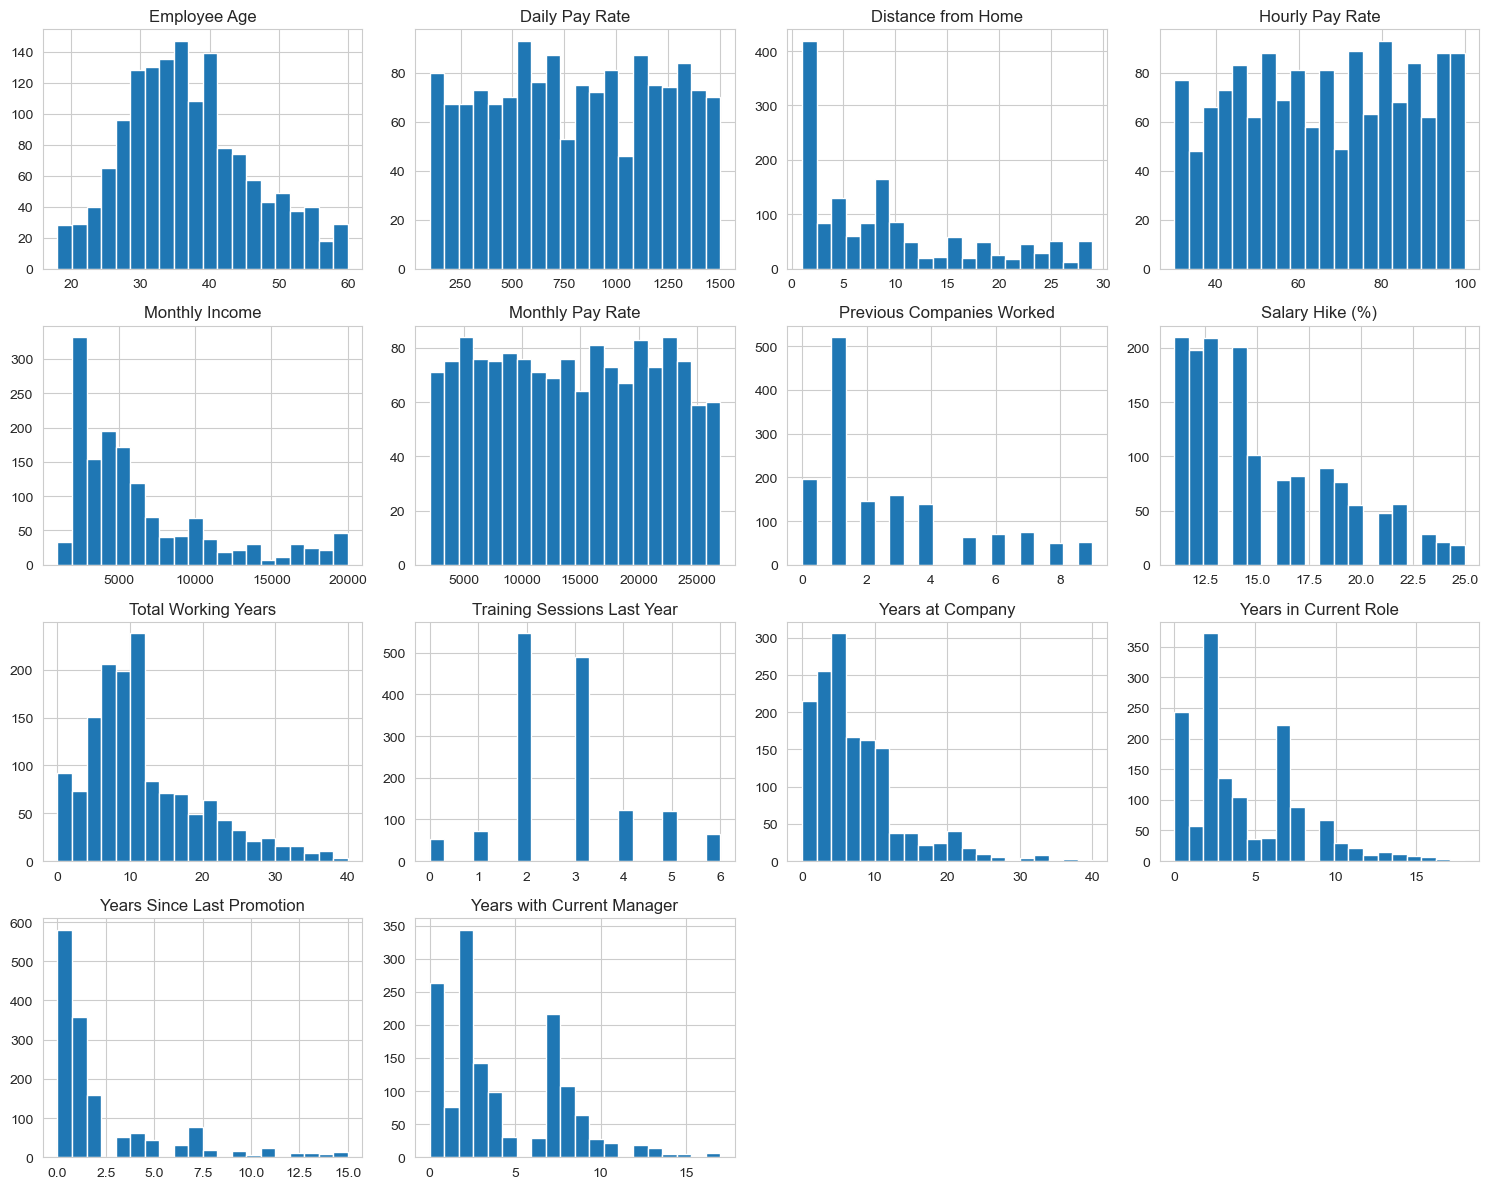

In [22]:
df_clean[true_numeric].hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

#### Description: 

Histograms are generated for all numerical variables to examine their distributions. Each histogram displays how employee values are spread across different ranges, allowing the analyst to observe the frequency of each value. Variables such as employee age, monthly income, total working years, and years at the company can be visually examined to identify patterns, skewness, concentration of values, and possible outliers.

Why this step is used:

Histograms help understand the distribution of numerical data before performing advanced analysis. They make it easier to identify whether the data is normally distributed, positively or negatively skewed, or contains unusual values. This understanding supports better decision-making during exploratory data analysis

In [23]:
for col in categorical:
    print(df_clean[col].value_counts(), "\n")

Attrition Status
No     1233
Yes     237
Name: count, dtype: int64 

Business Travel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64 

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64 

Education Field
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64 

Gender
Male      882
Female    588
Name: count, dtype: int64 

Job Role
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64 

Marital Status
Married     673
Single      470
Divorced    327
Name: count, dtype: int64 

Over

#### Description: 

The value_counts() function is used to calculate the frequency of each category in every categorical column. It displays the number of employees belonging to different groups, such as departments, job roles, education fields, gender, marital status, overtime, and business travel. This provides a clear understanding of how employees are distributed across different categories within the organization.

In [24]:
print(df_clean['Attrition Status'].value_counts())
print(df_clean['Attrition Status'].value_counts(normalize=True) * 100)

Attrition Status
No     1233
Yes     237
Name: count, dtype: int64
Attrition Status
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


#### Description: 

This step calculates both the count and percentage of employees who stayed and employees who left the organization. The value_counts() function returns the total number of employees in each attrition category, while the normalize=True parameter converts these counts into percentages. The results show that approximately 83.88% of employees stayed with the company, while 16.12% left the organization.

### STEP 5: Calculate KPIs

In [25]:
kpi_overall_attrition = df_clean['AttritionFlag'].mean() * 100
kpi_avg_tenure = df_clean['Years at Company'].mean()
kpi_avg_age = df_clean['Employee Age'].mean()
print("Overall attrition %:", round(kpi_overall_attrition, 2))
print("Avg tenure:", round(kpi_avg_tenure, 2))
print("Avg age:", round(kpi_avg_age, 2))

Overall attrition %: 16.12
Avg tenure: 7.01
Avg age: 36.92


#### Description: 

In this step, three important Key Performance Indicators (KPIs) are calculated to summarize the overall workforce. The first KPI calculates the overall employee attrition percentage by finding the average of the AttritionFlag column. The second KPI calculates the average number of years employees have worked in the company, while the third KPI calculates the average age of employees. These KPIs provide a quick overview of the organization's workforce and serve as important metrics for HR analysis.

Why this step is used:

KPIs summarize large amounts of employee data into a few meaningful metrics. They help management quickly understand workforce turnover, employee experience, and workforce demographics without analyzing the entire dataset. These KPIs are also useful for dashboards and executive reporting.

In [26]:
print(df_clean.groupby('Attrition Status')[['Monthly Income', 'Job Satisfaction', 'Work-Life Balance',
                                       'Distance from Home', 'Years Since Last Promotion']].mean())

                  Monthly Income  Job Satisfaction  Work-Life Balance  \
Attrition Status                                                        
No                   6832.739659          2.778589           2.781022   
Yes                  4787.092827          2.468354           2.658228   

                  Distance from Home  Years Since Last Promotion  
Attrition Status                                                  
No                          8.915653                    2.234388  
Yes                        10.632911                    1.945148  


#### Description:

The groupby() function is used to compare the average values of important employee attributes based on attrition status. It calculates the average monthly income, job satisfaction, work-life balance, distance from home, and years since the last promotion separately for employees who stayed and employees who left the organization. This comparison helps identify differences between the two employee groups.

Why this step is used:

Comparing employee characteristics based on attrition helps identify factors that may influence employees to leave the company. These insights allow HR teams to recognize potential problem areas and develop strategies to improve employee retention.

### STEP 6: Attrition by Segment

In [27]:
print(df_clean.groupby('Department')['AttritionFlag'].mean().sort_values(ascending=False) * 100)
print(df_clean.groupby('Job Role')['AttritionFlag'].mean().sort_values(ascending=False) * 100)
print(df_clean.groupby('Gender')['AttritionFlag'].mean() * 100)
print(df_clean.groupby('AgeBand', observed=True)['AttritionFlag'].mean() * 100)
print(df_clean.groupby('Marital Status')['AttritionFlag'].mean() * 100)
print(df_clean.groupby('Education Field')['AttritionFlag'].mean() * 100)
print(df_clean.groupby('Business Travel')['AttritionFlag'].mean() * 100)

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: AttritionFlag, dtype: float64
Job Role
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: AttritionFlag, dtype: float64
Gender
Female    14.795918
Male      17.006803
Name: AttritionFlag, dtype: float64
AgeBand
18-25    35.772358
26-35    19.141914
36-45     9.188034
46-55    11.504425
56-60    17.021277
Name: AttritionFlag, dtype: float64
Marital Status
Divorced    10.091743
Married     12.481426
Single      25.531915
Name: AttritionFlag, dtype: float64
Education Field
Human Resources     25.925926
Life Sciences       14.686469
Marketing           22.012579
Medi

#### Description:

In this step, employee attrition is analyzed across different organizational and demographic segments to identify which groups experience higher employee turnover. Instead of examining the overall attrition rate alone, the analysis breaks down the data into meaningful categories such as Department, Job Role, Gender, Age Band, Marital Status, Education Field, and Business Travel. The groupby() function is used to calculate the attrition percentage for each category by grouping employees with similar characteristics.

Segment-wise analysis helps uncover hidden patterns that may not be visible in the overall attrition statistics. By comparing attrition rates across different employee groups, the organization can identify departments, job roles, or employee segments that require more attention. These insights support HR teams in developing targeted retention strategies, improving employee satisfaction, and making informed workforce management decisions.

Why this step is used:

The overall attrition rate provides only a general view of employee turnover, but it does not explain which specific groups are more likely to leave the organization. Segment-wise analysis helps identify high-risk employee categories and the factors associated with higher attrition. This enables HR professionals and management to implement focused retention initiatives, improve workplace policies, and enhance employee engagement based on data-driven insights

### step 7:Salary, Overtime, Satisfaction, Work-Life Balance Patterns

In [28]:
print(df_clean.groupby('Overtime')['AttritionFlag'].mean() * 100)
print(df_clean.groupby('Work-Life Balance')['AttritionFlag'].mean() * 100)
print(df_clean.groupby('Job Satisfaction')['AttritionFlag'].mean() * 100)
print(df_clean.groupby('IncomeBand', observed=True)['AttritionFlag'].mean() * 100)

Overtime
No     10.436433
Yes    30.528846
Name: AttritionFlag, dtype: float64
Work-Life Balance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: AttritionFlag, dtype: float64
Job Satisfaction
1    22.837370
2    16.428571
3    16.515837
4    11.328976
Name: AttritionFlag, dtype: float64
IncomeBand
Low         29.268293
Mid-Low     14.207650
Mid-High    10.626703
High        10.326087
Name: AttritionFlag, dtype: float64


#### Description: 

In this step, the analysis focuses on identifying how important workplace and compensation-related factors influence employee attrition. The employee data is grouped based on Overtime, Work-Life Balance, Job Satisfaction, and Income Band, and the average attrition rate is calculated for each category using the groupby() function. This analysis helps compare employee turnover across different working conditions and salary levels to understand which factors have a greater impact on employees' decisions to leave the organization.

By examining these four factors together, the organization can identify patterns related to employee satisfaction, workload, and compensation. The results provide valuable insights into whether employees with poor work-life balance, lower job satisfaction, lower income, or frequent overtime are more likely to leave the company. These findings can help HR teams develop effective employee retention strategies, improve workplace policies, and create a healthier work environment.

Why this step is used:

This step is performed to identify the key factors that contribute to employee attrition. Understanding the relationship between overtime, work-life balance, job satisfaction, income level, and employee turnover helps the organization recognize potential causes of attrition. These insights support data-driven decision-making and enable HR professionals to implement targeted initiatives that improve employee satisfaction, increase retention, and reduce workforce turnover.

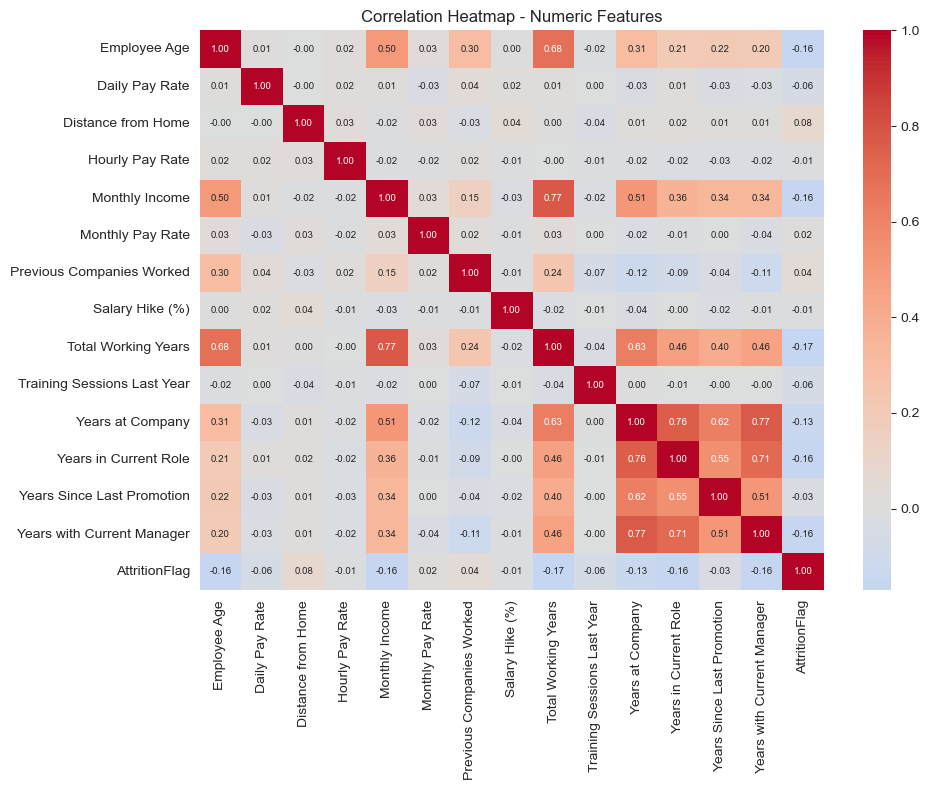

In [29]:
corr = df_clean[true_numeric + ['AttritionFlag']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 7})
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.savefig('10_correlation_heatmap.png')
plt.show()

#### Description:

A correlation matrix is created to measure the relationship between all numerical variables in the dataset. The results are displayed using a heatmap, where different colors represent the strength and direction of the correlation. Variables with positive correlations increase together, while negative correlations move in opposite directions. This visualization helps identify which numerical features have stronger relationships with employee attrition and with each other.

Why this step is used:

The correlation heatmap provides a quick overview of how numerical variables are related. It helps identify important factors influencing attrition, detect multicollinearity between variables, and support feature selection for future predictive modeling or advanced analysis.

### STEP 8: Visualizations (varied chart types, matched to each variable)

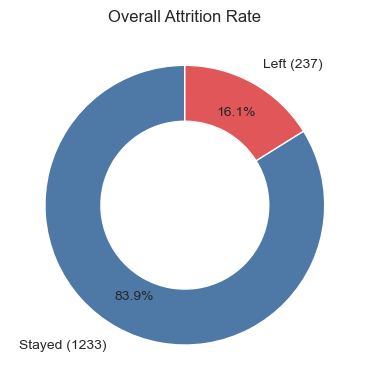

In [30]:
# 1. Overall Attrition -- donut (few categories, part-of-whole)
fig, ax = plt.subplots(figsize=(5,4))
counts = df_clean['Attrition Status'].value_counts()
ax.pie(counts, labels=[f'Stayed ({counts["No"]})', f'Left ({counts["Yes"]})'],
       autopct='%1.1f%%', colors=[COLOR_STAY, COLOR_LEFT], startangle=90, pctdistance=0.75, labeldistance=1.15,
       wedgeprops={'width': 0.4})
ax.set_title('Overall Attrition Rate')
plt.tight_layout(); plt.savefig('01_overall_attrition.png') 
plt.show()

#### Description:

In this step, a donut chart is created to visualize the overall distribution of employees who stayed in the organization and those who left. The chart displays both the employee count and the corresponding percentage for each attrition category. A donut chart is chosen instead of a regular pie chart because it provides a cleaner and more modern visualization while making the comparison between categories easier to understand.

Why this step is used:

The donut chart provides a quick overview of the overall attrition rate and clearly shows the proportion of employees who stayed versus those who left. It helps management quickly understand workforce turnover without analyzing numerical data.

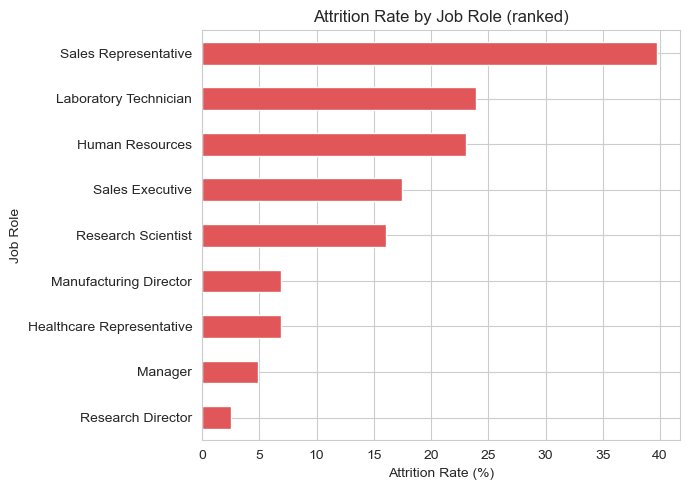

In [31]:
#2.Job Role -- ranked horizontal bar (9 categories, comparison matters)
fig, ax = plt.subplots(figsize=(7,5))
rate = df_clean.groupby('Job Role')['AttritionFlag'].mean().sort_values() * 100
rate.plot(kind='barh', ax=ax, color=COLOR_LEFT)
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Job Role (ranked)')
plt.tight_layout(); plt.savefig('03_jobrole_attrition.png'); plt.show()

#### Description:

A horizontal bar chart is created to compare attrition rates across different job roles. The job roles are arranged in ascending order of attrition percentage, making it easier to identify which positions experience the highest and lowest employee turnover. This visualization clearly highlights the job roles that require greater attention from the HR department.

Why this step is used:

A horizontal bar chart is suitable for comparing multiple job roles because it accommodates long category names and provides a clear ranking. It helps identify high-risk job positions where employee retention strategies may be required.

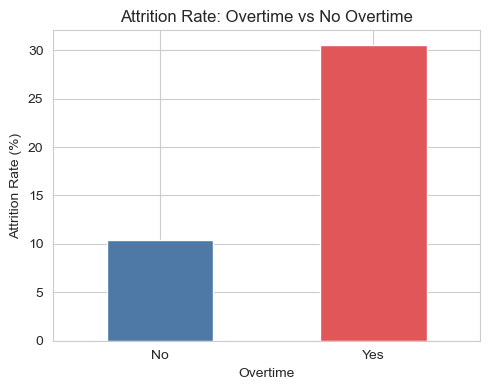

In [32]:
#3. Overtime -- simple 2-bar comparison
fig, ax = plt.subplots(figsize=(5,4))
rate = df_clean.groupby('Overtime')['AttritionFlag'].mean() * 100
rate.plot(kind='bar', ax=ax, color=[COLOR_STAY, COLOR_LEFT])
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Rate: Overtime vs No Overtime')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout(); plt.savefig('04_overtime_attrition.png'); plt.show()

#### Description:

This step creates a bar chart to compare employee attrition rates between employees who work overtime and those who do not. Each bar represents the percentage of employees leaving the organization for each overtime category, making the comparison simple and easy to interpret.

Why this step is used:

A bar chart is the most effective way to compare two categories. It clearly shows whether overtime has a significant impact on employee attrition and helps HR understand if workload management should be improved.

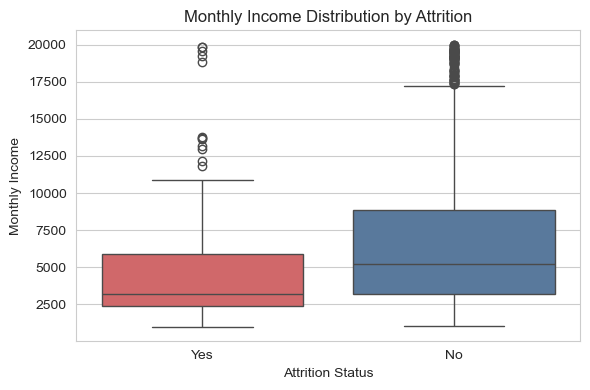

In [33]:
#4.Monthly Income -- boxplot (distribution, not just average)
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df_clean, x='Attrition Status', y='Monthly Income', hue='Attrition Status',
            palette={'No': COLOR_STAY, 'Yes': COLOR_LEFT}, legend=False, ax=ax)
ax.set_title('Monthly Income Distribution by Attrition')
plt.tight_layout(); plt.savefig('05_income_boxplot.png'); plt.show()

#### Description: 

A box plot is used to compare the distribution of monthly income between employees who stayed and employees who left the organization. The chart displays the median, quartiles, overall spread of income, and any potential outliers. This visualization provides a better understanding of salary distribution rather than simply comparing average income.

Why this step is used:

A box plot is useful for identifying differences in salary distribution and detecting outliers. It helps determine whether employee income has any relationship with attrition while showing the variability in salary among different employee groups.

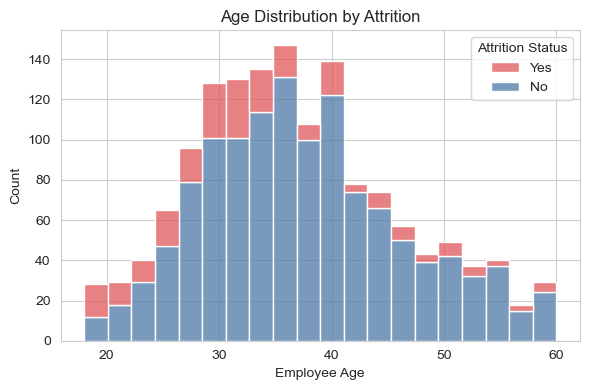

In [34]:
#5.Age -- stacked histogram (distribution)
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(data=df_clean, x='Employee Age', hue='Attrition Status', multiple='stack', bins=20,
             palette={'No': COLOR_STAY, 'Yes': COLOR_LEFT}, ax=ax)
ax.set_title('Age Distribution by Attrition')
plt.tight_layout(); plt.savefig('06_age_dist.png'); plt.show()

#### Description: 

A stacked histogram is created to visualize the age distribution of employees based on their attrition status. Employees are grouped into age intervals, and the chart displays the number of employees who stayed and those who left within each age group. This helps identify age ranges where employee turnover is more common.

Why this step is used:

A histogram is ideal for displaying the distribution of continuous numerical variables such as age. It helps identify age-related patterns in employee attrition and provides insights into which age groups require greater retention efforts.

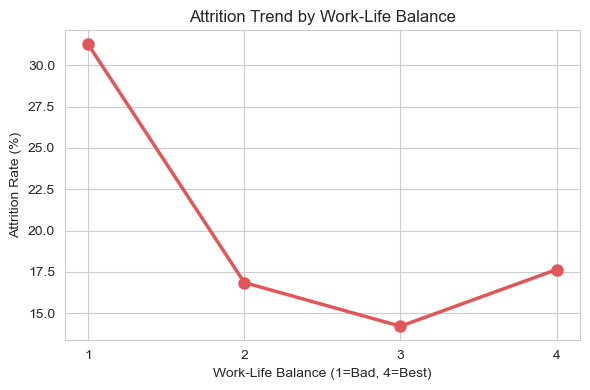

In [35]:
#6.Work-Life Balance -- line chart (ordered scale, shows trend)
fig, ax = plt.subplots(figsize=(6,4))
rate = df_clean.groupby('Work-Life Balance')['AttritionFlag'].mean() * 100
ax.plot(rate.index, rate.values, marker='o', color=COLOR_LEFT, linewidth=2.5, markersize=8)
ax.set_xlabel('Work-Life Balance (1=Bad, 4=Best)')
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Trend by Work-Life Balance')
ax.set_xticks(rate.index)
plt.tight_layout(); plt.savefig('07_wlb_attrition.png'); plt.show()

#### Description: 

A line chart is created to show how employee attrition changes across different work-life balance ratings. Each point on the line represents the attrition rate for a specific work-life balance level, making it easy to observe increasing or decreasing trends.

Why this step is used:

A line chart is appropriate because work-life balance follows an ordered rating scale. It effectively displays trends and helps determine whether improvements in work-life balance are associated with lower employee attrition.

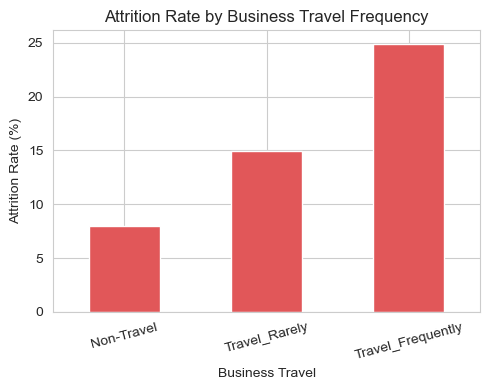

In [36]:
#7.Business Travel -- sorted bar
fig, ax = plt.subplots(figsize=(5,4))
rate = df_clean.groupby('Business Travel')['AttritionFlag'].mean() * 100
rate.sort_values().plot(kind='bar', ax=ax, color=COLOR_LEFT)
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Business Travel Frequency')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
plt.tight_layout(); plt.savefig('12_travel_attrition.png'); plt.show()

#### Description: 

A bar chart is created to compare employee attrition rates across different business travel categories, such as Travel Rarely, Travel Frequently, and Non-Travel. The chart highlights how travel frequency influences employee turnover and allows easy comparison between the different travel groups.

Why this step is used:

Bar charts are effective for comparing categorical variables. This visualization helps identify whether employees who travel frequently are more likely to leave the organization than employees with less or no business travel.

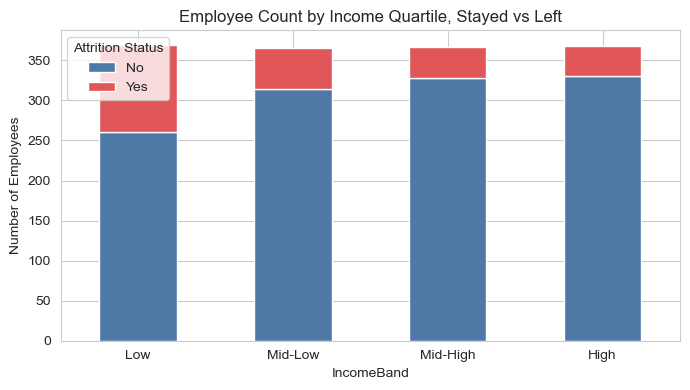

In [37]:
#8.Income Band -- stacked bar (raw counts, not rate)
fig, ax = plt.subplots(figsize=(7,4))
pivot = df_clean.groupby(['IncomeBand', 'Attrition Status'], observed=True).size().unstack()
pivot = pivot.reindex(['Low', 'Mid-Low', 'Mid-High', 'High'])
pivot.plot(kind='bar', stacked=True, ax=ax, color=[COLOR_STAY, COLOR_LEFT])
ax.set_ylabel('Number of Employees')
ax.set_title('Employee Count by Income Quartile, Stayed vs Left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout(); plt.savefig('15_incomeband_stacked.png'); plt.show()

#### Description: 

In this step, a stacked bar chart is created to compare the number of employees who stayed and those who left across different income bands. The chart displays employee counts rather than percentages, allowing the organization to observe the distribution of employees within each salary category and compare attrition across different income levels.

Why this step is used:

A stacked bar chart is suitable for comparing the composition of multiple categories simultaneously. It helps visualize how employee retention varies across income groups and whether lower or higher salary bands contain more employees who left the organization.

## Final Conclusion

The data cleaning and exploratory data analysis (EDA) of the Employee Attrition dataset were completed successfully. During the data cleaning process, the dataset was checked for missing values, duplicate records, and unnecessary columns to ensure data quality. Constant columns were removed, categorical values were standardized, and new features such as AttritionFlag, AgeBand, and IncomeBand were created to make the analysis more meaningful.

After cleaning, exploratory data analysis was performed to understand employee attrition from different perspectives. Various analyses were carried out based on departments, job roles, age groups, gender, marital status, business travel, overtime, job satisfaction, work-life balance, and income levels. KPIs, correlation analysis, and different visualizations were also created to identify important trends and patterns in the dataset.

Overall, the analysis provided valuable insights into the factors associated with employee attrition and produced a clean, well-structured dataset suitable for dashboard creation and further business analysis. The findings can help HR teams understand employee turnover patterns and support better workforce planning and employee retention strategies.

# POWER BI DATA TRANSFORMATION

##### After completing the data cleaning and exploratory data analysis (EDA) in Python, the final cleaned dataset was imported into Power BI Desktop using the Get Data option. The dataset was then opened in Power Query Editor to perform additional business-friendly transformations before creating the dashboard.

#### Verifying Data Types

#### Objective

To ensure that each column had the correct data type for accurate calculations, filtering, and visualization.

##### All imported columns were reviewed in Power Query Editor. Numeric columns were verified as Whole Number or Decimal Number, while categorical columns were checked as Text.

##### Why this step was performed

Correct data types improve calculation accuracy and prevent errors in DAX measures and dashboard visuals.

#### Result

The dataset contained appropriate data types for all columns before further transformation.

#### - Converting Education Codes into Descriptive Labels

The Education column originally stored values from 1 to 5, representing different education levels. These numeric codes were replaced with descriptive text labels.

#### Result

The Education column was converted from numeric codes into meaningful education categories.

#### - Converting Environment Satisfaction Ratings

##### Numeric satisfaction ratings were converted into descriptive text labels.

Result:
The Environment Satisfaction column now displays meaningful satisfaction levels.

#### - Converting Job Involvement Ratings

##### To improve the readability of employee involvement levels in reports and dashboard visuals.

Result:
The Job Involvement column now contains descriptive values instead of numeric codes.

#### - Converting Job Satisfaction Ratings

#### To make employee satisfaction information easier to interpret in dashboard visualizations.

Result:
The Job Satisfaction column was successfully converted into descriptive categories.

#### - Converting Relationship Satisfaction Ratings

#### To improve the interpretability of relationship satisfaction across different employee groups.

Result:
The Relationship Satisfaction column now contains business-friendly values.

#### - Converting Work-Life Balance Ratings

#### Replacing numeric values with descriptive labels makes dashboard insights easier to understand.

Result:
The Work-Life Balance column now displays descriptive work-life categories.

#### - Converting Performance Rating

#### To display meaningful employee performance ratings instead of numeric codes.

Result:
The Performance Rating column now contains descriptive performance categories.

#### - Converting Job Level

#### Job levels represented by numbers can be difficult to interpret. Converting them into descriptive labels improves the clarity of dashboard visuals.

Result:
The Job Level column became more meaningful and user-friendly.

##### After verifying all transformations, the Close & Apply option was used to apply the changes and load the transformed dataset into Power BI.

##### Uploading Some Images From My Power Query

![Power Query 1](Power_query1.png)

![Power Query 2](Power_query2.png)

![Power Query 3](Power_query3.png)

### DASHBOARD DEVELOPMENT

#### Objective

The HR Analytics Dashboard was developed in Microsoft Power BI to provide an interactive platform for analyzing employee attrition. The dashboard combines KPI cards, DAX measures, slicers, and various visualizations to monitor workforce performance, identify attrition patterns, and support data-driven HR decision-making.

##### The dashboard consists of two pages:

Page 1: Employee Attrition Overview

Page 2: Employee Attrition Insights

Together, these pages provide both executive-level summaries and detailed analytical insights into employee attrition.

#### DAX Measures Created

##### Total Employees: Counts the total number of employees available in the HR dataset.
Purpose:
Acts as the primary KPI representing the organization's total workforce.

Total Employees =COUNT('HR DATA'[Employee ID])

#### Measure 2: Employees Left

##### Calculates the total number of employees who have left the organization.

Purpose:
Measures workforce attrition and supports turnover analysis.

Employees Left =
CALCULATE(
COUNT('HR DATA'[Employee ID]),
'HR DATA'[Attrition Status]="Yes"
)

#### Measure 3: Attrition Rate

##### Calculates the percentage of employees who left the organization.

Purpose:
Provides an overall employee turnover percentage.

Attrition Rate =
DIVIDE([Employees Left],[Total Employees])

#### Measure 4: Average Working Years

##### Calculates the average total working experience of employees.

Purpose
Represents the overall experience level of the workforce.

Average Working Years =
AVERAGE('HR DATA'[Total Working Years])

#### Measure 5: Average Monthly Income

##### Calculates the average monthly salary of employees.

Purpose:
Provides an overview of employee compensation.

Average Monthly Income =
AVERAGE('HR DATA'[Monthly Income])

### KPI Cards

##### 1. Total Employees: Displays the total number of employees available in the organization.

Business Purpose:
Provides the overall workforce size.

##### 2. Employees Left: Shows the number of employees who left the organization.

Business Purpose:
Measures total employee turnover.

##### 3. Average Working Years: Displays the average years of work experience among employees.

Business Purpose:
Helps understand the overall workforce experience.

##### 4. Attrition Rate: Displays the percentage of employees who left the organization.

Business Purpose:
Measures the overall employee retention performance.

##### 5. Average Monthly Income: Displays the average monthly salary of employees.

Business Purpose:
Provides an overview of workforce compensation.

### Dashboard Filters

##### Department

Filters the dashboard by department to analyze department-specific attrition.

##### Age Band

Allows users to analyze employee attrition across different age groups.

##### Gender

Filters dashboard visuals based on employee gender.

##### Marital Status

Allows analysis of employee attrition by marital status.

### Dashboard Visualizations

##### Department-wise Attrition
Visual-1

Clustered Bar Chart

Description:
Displays the number of employees who left each department.

Purpose:
Identifies departments experiencing higher employee turnover.

##### Attrition by Gender
Visual-2

Clustered Column Chart

Description:
Compares employee attrition between male and female employees.

Purpose:
Analyzes gender-wise attrition trends.

##### Job Role Attrition
Visual-3

Horizontal Bar Chart

Description:
Displays employee attrition across different job roles.

Purpose:
Identifies job roles with higher employee turnover.

##### Gender Distribution
Visual-4

Donut Chart

Description:
Shows the distribution of male and female employees.

Purpose:
Provides demographic information about the workforce.

##### Overtime Impact
Visual-5

Clustered Column Chart

Description:
Compares employee attrition based on overtime status.

Purpose:
Analyzes whether overtime influences employee turnover.

##### Age Band Attrition
Visual-6

Horizontal Bar Chart

Description:
Displays employee attrition across different age groups.

Purpose:
Identifies age groups with higher employee turnover.

##### Employees Left by Business Travel
Visual-7

Donut Chart

Description:
Displays employee attrition across different business travel categories.

Purpose:
Evaluates the impact of business travel on employee attrition.

![Dashboard Page 1](Dashboard_page1.png)

### Summary of Page 1: 
The first dashboard page provides an executive-level overview of employee attrition through key performance indicators, interactive filters, and summary visualizations. It enables HR managers to quickly monitor workforce trends and identify departments or employee groups requiring further investigation.

## Dashboard Page 2

### HR Analytics | Employee Attrition Insights

#### Objective

The second dashboard page focuses on analyzing the major factors influencing employee attrition. It examines employee satisfaction, education, promotions, salary, work-life balance, and job level to identify the key drivers of employee turnover.

#### Dashboard Filters

##### Department

Filters all visualizations by department.

##### Gender

Filters dashboard analysis based on employee gender.

##### Job Role

Allows analysis of attrition for individual job roles.

##### Overtime

Filters employees based on overtime status.

### Dashboard Visualizations

##### Job Satisfaction vs Attrition
Visual-1

Clustered Column Chart

Description:
Compares employee attrition across different job satisfaction levels.

Purpose:
Determines whether lower job satisfaction contributes to employee attrition.

##### Environment Satisfaction vs Attrition
Visual-2

Clustered Bar Chart

Description:
Analyzes employee attrition based on workplace environment satisfaction.

Purpose:
Evaluates the influence of workplace environment on employee retention.

##### Education Level vs Attrition
Visual-3

Clustered Bar Chart

Description:
Displays employee attrition across different education levels.

Purpose:
Identifies education groups experiencing higher employee turnover.

##### Years Since Last Promotion vs Attrition
Visual-4

Line Chart

Description:
Shows the relationship between the number of years since an employee's last promotion and employee attrition.

Purpose:
Analyzes whether delayed promotions contribute to employee turnover.

##### Work-Life Balance vs Attrition
Visual-5

Clustered Column Chart

Description:
Displays employee attrition across different work-life balance levels.

Purpose:
Evaluates the impact of work-life balance on employee retention.

##### Monthly Income vs Years at Company
Visual-6

Scatter Chart

Description:
Shows the relationship between employee monthly income and years at the company while distinguishing employees by attrition status.

Purpose:
Analyzes whether salary and work experience influence employee retention.

##### Job Level vs Attrition
Visual-7

Clustered Column Chart

Description:
Displays employee attrition across different job levels.

Purpose:
Identifies job levels with higher employee turnover.

##### Relationship Satisfaction vs Attrition
Visual-8

Clustered Column Chart

Description:
Displays employee attrition across different relationship satisfaction levels.

Purpose:
Evaluates whether workplace relationships influence employee retention.

![Dashboard page 2](Dashboard_page2.png)

#### Summary of Page 2

The second dashboard page provides detailed analytical insights into the factors contributing to employee attrition. By examining employee satisfaction, work-life balance, salary, promotions, education level, job level, and workplace relationships, the dashboard enables HR managers to identify high-risk employee groups and implement targeted employee retention strategies.

### Key Insights from the Analysis
- The overall employee attrition rate is 16.12%, with 237 employees leaving the organization.
- The Research & Development department experienced the highest attrition.
- Employees aged 26–35 years showed the highest turnover.
- Employees working overtime were more likely to leave the company.
- Lower job satisfaction, environment satisfaction, and work-life balance were associated with higher attrition.
- Employees with longer periods without promotion showed a greater tendency to leave.
- Higher monthly income generally corresponded with longer employee retention.
- Lower job levels recorded higher attrition compared to senior positions.

### Business Recommendations to Reduce Employee Attrition
- Reduce employee overtime to improve work-life balance.
- Provide clear career growth opportunities and timely promotions.
- Improve employee engagement through regular feedback and recognition.
- Focus retention strategies on high-attrition departments, especially Research & Development and Sales.
- Strengthen manager–employee relationships through leadership training.
- Review compensation and benefits regularly to remain competitive.
- Continue monitoring attrition trends using the Power BI dashboard for data-driven HR decisions.

### Final Dashboard Conclusion

The Power BI dashboard successfully transformed the cleaned HR dataset into an interactive business intelligence solution. Using DAX measures, KPI cards, slicers, and analytical visualizations, the dashboard provides comprehensive insights into employee attrition and supports data-driven HR decision-making. The two-page design enables users to view both high-level organizational metrics and detailed attrition analysis, making it an effective decision-support tool for improving employee retention and workforce planning.

#### Business Insights

The HR Analytics dashboard provided valuable insights into the factors influencing employee attrition within the organization. By analyzing employee demographics, job-related attributes, and workplace satisfaction, several important business findings were identified.

### 1. Employee Attrition Rate is Significant

The overall employee attrition rate is **16.12%**, with **237 employees leaving** out of **1,470 employees**. This indicates that employee turnover is a considerable challenge and requires strategic attention to improve workforce stability and reduce replacement costs.

### 2. Research & Development Department Experiences the Highest Attrition

Among all departments, the **Research & Development** department recorded the highest number of employees leaving, followed by the **Sales** department. This suggests that these departments may be experiencing higher work pressure, limited career growth opportunities, or reduced employee satisfaction.

### 3. Employees Aged 26–35 are More Likely to Leave

The analysis revealed that employees in the **26–35 age group** have the highest attrition. This age group generally represents employees seeking faster career growth, better compensation, and professional development opportunities, making them more likely to switch organizations.

### 4. Overtime has a Strong Impact on Attrition

Employees who regularly work **overtime** show a much higher attrition rate compared to employees who do not. This indicates that excessive workload and work-related stress significantly influence employees' decisions to leave the organization.

### 5. Job Role Influences Employee Turnover

Certain job roles such as **Laboratory Technician**, **Sales Executive**, and **Research Scientist** experienced higher employee attrition than other roles. This highlights the need for role-specific retention strategies and workload management.

### 6. Lower Job Satisfaction and Work-Life Balance Increase Attrition

Employees reporting **low job satisfaction**, **poor work-life balance**, and **lower environment satisfaction** were more likely to leave the organization. Employee engagement and workplace culture play a crucial role in improving retention.

### 7. Employees with Lower Job Levels Leave More Frequently

Employees in **Job Level 1** recorded the highest attrition compared to higher job levels. Entry-level employees may seek better career opportunities, higher salaries, or faster promotions elsewhere.

### 8. Limited Career Growth Contributes to Attrition

Employees with **more years since their last promotion** tend to leave more frequently. This indicates that delayed promotions and limited career advancement opportunities reduce employee motivation and increase turnover.

### 9. Monthly Income Influences Employee Retention

The analysis shows that employees with **lower monthly income** are more likely to leave the organization. Competitive salary structures and performance-based rewards can improve employee retention.

### 10. Business Travel Shows Moderate Impact on Attrition

Employees who **travel frequently** or **travel rarely** experienced relatively higher attrition than employees who do not travel. Frequent travel may contribute to work-life imbalance and increased job stress for certain employees.

### 11. Education Level and Marital Status also Influence Attrition

Employees with **Bachelor's degrees** represented a larger share of employees leaving the organization. Additionally, **single employees** showed relatively higher attrition compared to married employees, indicating that personal and demographic factors also influence retention.

### 12. Interactive Dashboard Supports Better Decision-Making

The Power BI dashboard enables HR managers to monitor employee attrition through **interactive KPIs, filters, slicers, and visualizations**. It helps identify high-risk employee groups, analyze workforce trends, and supports data-driven HR decision-making for improving employee retention.
